PROCESO OPTIMIZADO CON BÚSQUEDA DE CARACTERÍSTICAS Y ENFOQUE EN PICOS

Cargando datos de entrenamiento desde: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20\2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx
Datos de entrenamiento: 216 muestras, 171 características
Iniciando ingeniería de atributos optimizada...
Escalando características...
Características después de ingeniería: 198

BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS

Probando con 10 características...
  MAE: 6.4448, R²: 0.8672, RMSE: 8.9658
  MAE en picos (>P90): 14.7033

Probando con 15 características...
  MAE: 6.3262, R²: 0.8757, RMSE: 8.6746
  MAE en picos (>P90): 12.8419

Probando con 20 características...
  MAE: 6.3155, R²: 0.8796, RMSE: 8.5383
  MAE en picos (>P90): 13.0096

Probando con 25 características...
  MAE: 6.0632, R²: 0.8801, RMSE: 8.5182
  MAE en picos (>P90): 12.5304

Probando con 30 características...
  MAE: 6.5794, R²: 0.8638, RMSE: 9.0814
  MAE

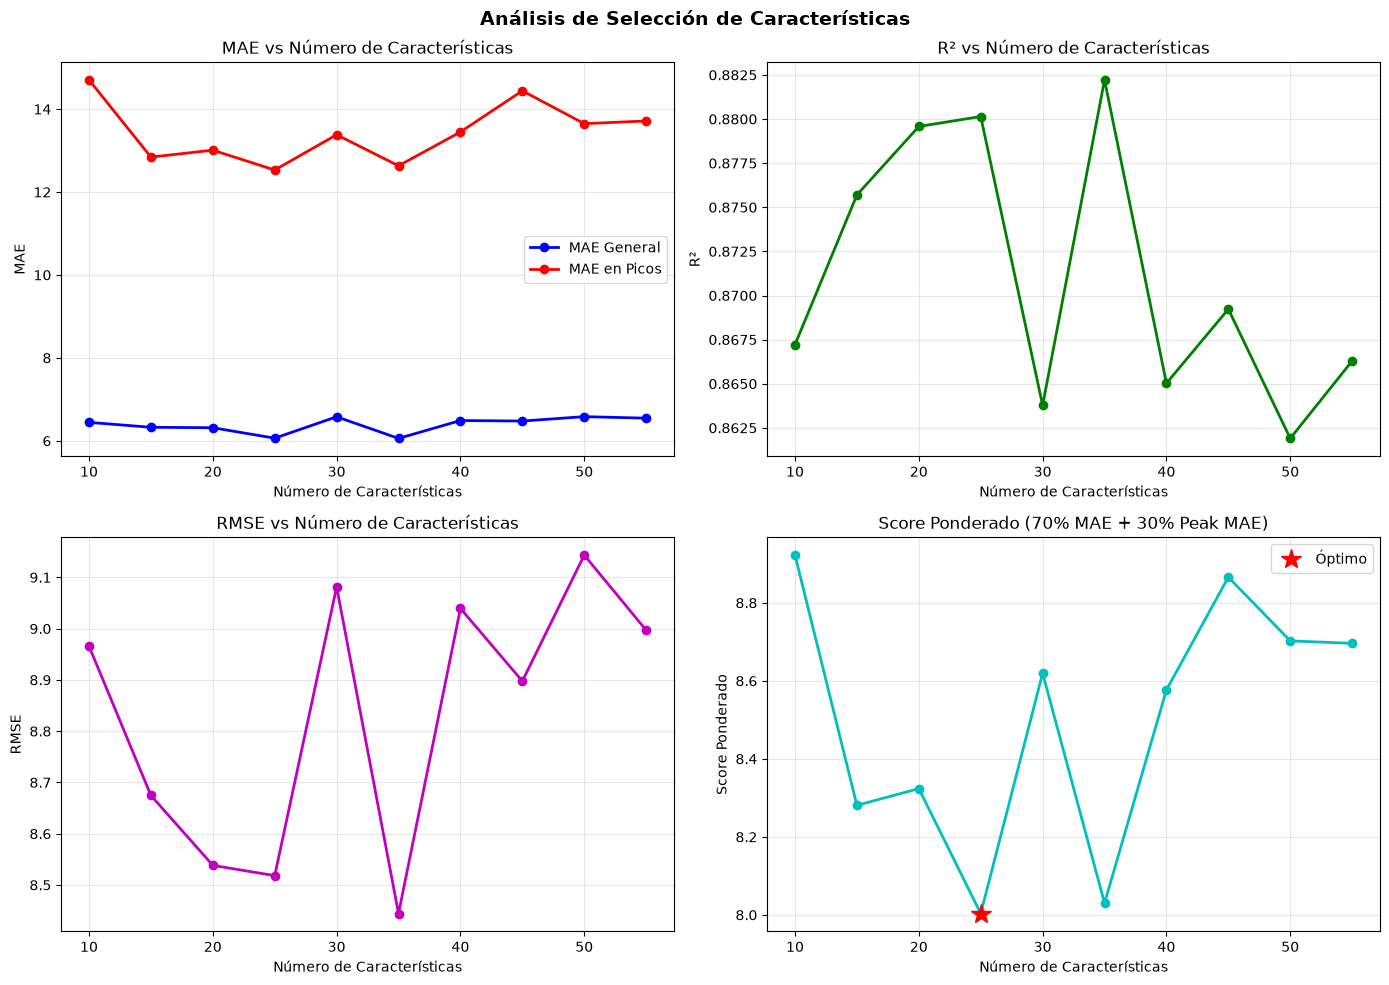

✅ Análisis de picos guardado en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20\peak_analysis.png


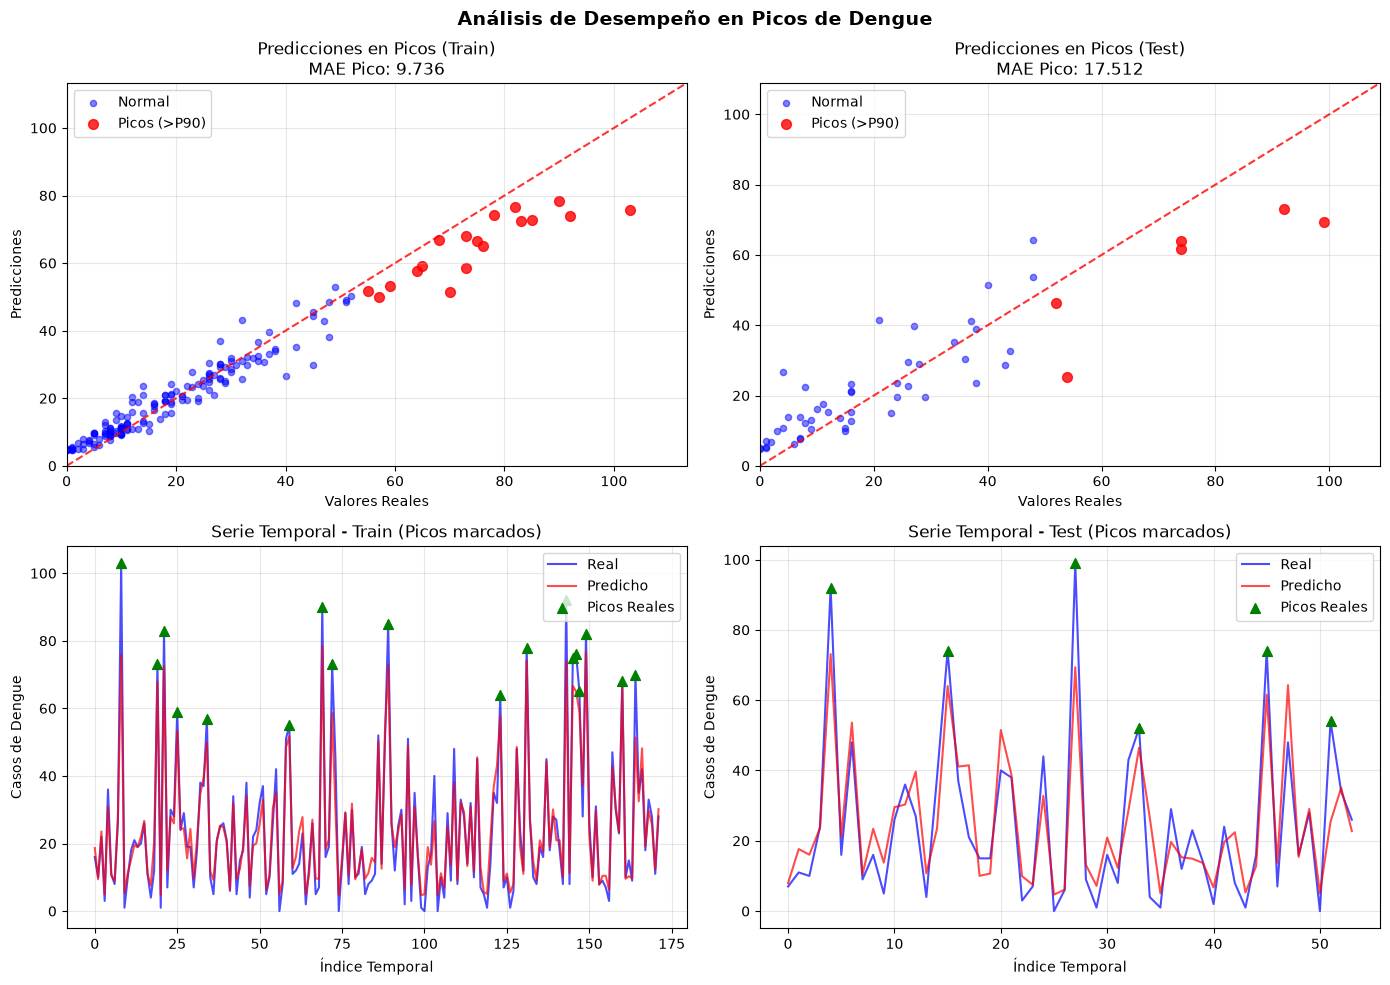


PROCESO COMPLETADO EXITOSAMENTE
Resultados guardados en: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20\resultados_optimizados_picos.xlsx
Análisis de selección: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20\feature_selection_analysis.png
Análisis de picos: C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20\peak_analysis.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import warnings
import os
from datetime import datetime
warnings.filterwarnings('ignore')

class DengueFeatureEngineeringOptimized:
    def __init__(self, n_features_to_select=25):
        """
        Clase optimizada para ingeniería de atributos y reducción de overfitting
        """
        self.n_features_to_select = n_features_to_select
        self.scaler = StandardScaler()
        self.rfe = None
        self.selected_features = None
        self.feature_names = None
        self.xgb_model = None
        self.numeric_columns = None
        self.feature_importance_df = None
        self.best_params = None
        self.peak_mae = None
        self.X_augmented_columns = None  # Guardar columnas para transformación
        
    def create_interaction_features(self, X):
        """Crea características de interacción seleccionadas estratégicamente"""
        interaction_data = pd.DataFrame(index=X.index)
        
        interactions = [
            ('temp', 'hum_rel', 'temp_hum_rel'),
            ('temp_max', 'hum_rel', 'temp_max_hum_rel'),
            ('prec', 'temp', 'prec_temp'),
            ('dias_lluvia', 'hum_rel', 'dias_lluvia_hum_rel'),
            ('soi', 'sst', 'soi_sst'),
            ('temp', 'soi', 'temp_soi'),
        ]
        
        for col1, col2, new_col in interactions:
            if col1 in X.columns and col2 in X.columns:
                interaction_data[new_col] = X[col1] * X[col2]
        
        return interaction_data
    
    def create_polynomial_features(self, X):
        """Crea características polinomiales solo para variables clave"""
        important_vars = ['temp', 'hum_rel', 'prec']
        poly_features = pd.DataFrame(index=X.index)
        
        for var in important_vars:
            if var in X.columns:
                poly_features[f'{var}_squared'] = X[var] ** 2
        
        return poly_features
    
    def create_lag_aggregates(self, X):
        """Crea agregados de rezagos con regularización"""
        lag_aggs = pd.DataFrame(index=X.index)
        
        for base_var in ['temp', 'temp_max', 'temp_min', 'hum_rel', 'prec', 'dias_lluvia']:
            lag_cols = [col for col in X.columns if col.startswith(f'{base_var}_lag_')]
            if len(lag_cols) >= 3:
                lag_data = X[lag_cols]
                lag_aggs[f'{base_var}_lag_mean'] = lag_data.mean(axis=1)
                lag_aggs[f'{base_var}_lag_std'] = lag_data.std(axis=1)
        
        dengue_lag_cols = [col for col in X.columns if col.startswith('casos_dengue_lag_')]
        if len(dengue_lag_cols) >= 3:
            dengue_lag_data = X[dengue_lag_cols]
            lag_aggs['dengue_lag_mean'] = dengue_lag_data.mean(axis=1)
            lag_aggs['dengue_lag_std'] = dengue_lag_data.std(axis=1)
            lag_aggs['dengue_lag_sum'] = dengue_lag_data.sum(axis=1)
        
        return lag_aggs
    
    def create_rolling_features(self, X):
        """Crea características de tendencia temporal simplificadas"""
        rolling_features = pd.DataFrame(index=X.index)
        
        if 'semana_epi' in X.columns:
            rolling_features['week_sin'] = np.sin(2 * np.pi * X['semana_epi'] / 52)
            rolling_features['week_cos'] = np.cos(2 * np.pi * X['semana_epi'] / 52)
        
        if 'casos_dengue_lag_12' in X.columns:
            if 'casos_dengue_lag_8' in X.columns:
                rolling_features['dengue_trend_4weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_8']
            if 'casos_dengue_lag_4' in X.columns:
                rolling_features['dengue_trend_8weeks'] = X['casos_dengue_lag_12'] - X['casos_dengue_lag_4']
        
        return rolling_features
    
    def get_numeric_columns(self, X):
        """Identifica columnas numéricas"""
        exclude_cols = ['fecha', 'date', 'datetime', 'timestamp']
        numeric_cols = []
        
        for col in X.columns:
            if col.lower() in exclude_cols:
                continue
            if pd.api.types.is_numeric_dtype(X[col]):
                numeric_cols.append(col)
        
        return numeric_cols
    
    def augment_features(self, X):
        """Aplica ingeniería de atributos a cualquier conjunto de datos"""
        # Identificar columnas numéricas
        numeric_cols = self.get_numeric_columns(X)
        X_numeric = X[numeric_cols]
        
        # Crear características
        features_list = [X_numeric]
        
        interaction_features = self.create_interaction_features(X_numeric)
        if not interaction_features.empty:
            features_list.append(interaction_features)
        
        poly_features = self.create_polynomial_features(X_numeric)
        if not poly_features.empty:
            features_list.append(poly_features)
        
        lag_aggs = self.create_lag_aggregates(X_numeric)
        if not lag_aggs.empty:
            features_list.append(lag_aggs)
        
        rolling_features = self.create_rolling_features(X_numeric)
        if not rolling_features.empty:
            features_list.append(rolling_features)
        
        X_augmented = pd.concat(features_list, axis=1)
        
        # Limpiar datos
        X_augmented = X_augmented.replace([np.inf, -np.inf], np.nan)
        X_augmented = X_augmented.fillna(X_augmented.mean())
        
        return X_augmented, X_numeric
    
    def fit_transform(self, X, y=None):
        """Aplica transformaciones con regularización"""
        print("Iniciando ingeniería de atributos optimizada...")
        
        # Aplicar ingeniería de atributos
        X_augmented, X_numeric = self.augment_features(X)
        
        # Guardar columnas numéricas y aumentadas para transformación
        self.numeric_columns = X_numeric.columns.tolist()
        self.X_augmented_columns = X_augmented.columns.tolist()
        self.feature_names = X_augmented.columns.tolist()
        
        # Escalar
        print("Escalando características...")
        X_scaled = pd.DataFrame(
            self.scaler.fit_transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        print(f"Características después de ingeniería: {X_augmented.shape[1]}")
        
        return X_scaled, X_augmented
    
    def transform_features(self, X):
        """Aplica transformación a nuevos datos"""
        # Aplicar la misma ingeniería de atributos
        X_augmented, X_numeric = self.augment_features(X)
        
        # Asegurar que las columnas coincidan con las del entrenamiento
        # Si faltan columnas, agregarlas con ceros
        for col in self.X_augmented_columns:
            if col not in X_augmented.columns:
                X_augmented[col] = 0
        
        # Reordenar columnas para que coincidan con el entrenamiento
        X_augmented = X_augmented[self.X_augmented_columns]
        
        # Escalar usando el scaler entrenado
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_augmented),
            columns=X_augmented.columns,
            index=X_augmented.index
        )
        
        return X_scaled
    
    def find_optimal_features(self, X_scaled, y, feature_range=None):
        """
        Encuentra el número óptimo de características usando búsqueda exhaustiva
        con enfoque en predicción de picos
        """
        if feature_range is None:
            feature_range = range(10, min(80, X_scaled.shape[1]), 5)
        
        print("\n" + "="*60)
        print("BÚSQUEDA DEL NÚMERO ÓPTIMO DE CARACTERÍSTICAS")
        print("="*60)
        
        results = []
        best_mae = float('inf')
        best_peak_mae = float('inf')
        best_n_features = None
        best_rfe = None
        best_selected = None
        
        # Dividir datos para validación
        X_train_val, X_val, y_train_val, y_val = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )
        
        for n_features in feature_range:
            print(f"\nProbando con {n_features} características...")
            
            # RFE con Random Forest
            rf = RandomForestRegressor(
                n_estimators=100,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            )
            
            rfe = RFE(
                estimator=rf,
                n_features_to_select=n_features,
                step=3,
                verbose=0
            )
            
            X_train_selected = rfe.fit_transform(X_train_val, y_train_val)
            X_val_selected = rfe.transform(X_val)
            
            # Entrenar XGBoost
            params = {
                'n_estimators': 200,
                'max_depth': 4,
                'learning_rate': 0.03,
                'subsample': 0.7,
                'colsample_bytree': 0.7,
                'min_child_weight': 5,
                'gamma': 0.5,
                'reg_alpha': 0.5,
                'reg_lambda': 2.0,
                'random_state': 42
            }
            
            model = xgb.XGBRegressor(**params)
            model.fit(X_train_selected, y_train_val)
            
            # Evaluar en validación
            y_pred = model.predict(X_val_selected)
            
            # Métricas generales
            mae = mean_absolute_error(y_val, y_pred)
            r2 = r2_score(y_val, y_pred)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            
            # Métricas específicas para picos (valores > percentil 90)
            peak_threshold = np.percentile(y_val, 90)
            peak_mask = y_val > peak_threshold
            peak_mae = mean_absolute_error(y_val[peak_mask], y_pred[peak_mask]) if np.sum(peak_mask) > 0 else float('inf')
            
            print(f"  MAE: {mae:.4f}, R²: {r2:.4f}, RMSE: {rmse:.4f}")
            print(f"  MAE en picos (>P90): {peak_mae:.4f}")
            
            # Guardar resultados
            results.append({
                'n_features': n_features,
                'mae': mae,
                'r2': r2,
                'rmse': rmse,
                'peak_mae': peak_mae,
                'peak_threshold': peak_threshold,
                'n_peaks': np.sum(peak_mask)
            })
            
            # Actualizar mejor según criterios ponderados
            weighted_score = 0.7 * mae + 0.3 * peak_mae if peak_mae != float('inf') else mae
            
            if weighted_score < best_mae:
                best_mae = weighted_score
                best_peak_mae = peak_mae
                best_n_features = n_features
                best_rfe = rfe
                best_selected = X_scaled.columns[rfe.support_].tolist()
        
        print("\n" + "="*60)
        print(f"✅ NÚMERO ÓPTIMO DE CARACTERÍSTICAS: {best_n_features}")
        print(f"   MAE ponderado: {best_mae:.4f}")
        print(f"   MAE en picos: {best_peak_mae:.4f}")
        print("="*60)
        
        # Guardar resultados
        self.selected_features = best_selected
        self.rfe = best_rfe
        self.feature_selection_results = pd.DataFrame(results)
        
        return best_n_features, results
    
    def transform_with_selected_features(self, X_scaled):
        """Transforma usando las características seleccionadas"""
        X_final = X_scaled[self.selected_features]
        return X_final
    
    def train_xgboost_final(self, X_train, y_train, X_val, y_val):
        """Entrena modelo final XGBoost con regularización"""
        print("\nEntrenando modelo final XGBoost...")
        
        params = {
            'n_estimators': 300,
            'max_depth': 4,
            'learning_rate': 0.03,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'min_child_weight': 5,
            'gamma': 0.5,
            'reg_alpha': 0.5,
            'reg_lambda': 2.0,
            'random_state': 42,
            'early_stopping_rounds': 50,
            'eval_metric': 'mae',
            'verbose': 0
        }
        
        eval_set = [(X_train, y_train), (X_val, y_val)]
        
        self.xgb_model = xgb.XGBRegressor(**params)
        self.xgb_model.fit(
            X_train,
            y_train,
            eval_set=eval_set,
            verbose=False
        )
        
        print("Modelo final entrenado exitosamente")
        
        return self.xgb_model
    
    def evaluate_model_detailed(self, X_test, y_test, dataset_name="Test"):
        """Evalúa el modelo con métricas detalladas incluyendo picos"""
        y_pred = self.xgb_model.predict(X_test)
        
        # Métricas generales
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Métricas para picos (percentiles)
        peak_metrics = {}
        for p in [90, 95, 97.5]:
            threshold = np.percentile(y_test, p)
            peak_mask = y_test > threshold
            if np.sum(peak_mask) > 0:
                peak_mae = mean_absolute_error(y_test[peak_mask], y_pred[peak_mask])
                peak_r2 = r2_score(y_test[peak_mask], y_pred[peak_mask]) if len(y_test[peak_mask]) > 1 else np.nan
                peak_metrics[f'P{p}_MAE'] = peak_mae
                peak_metrics[f'P{p}_R2'] = peak_r2
                peak_metrics[f'P{p}_Threshold'] = threshold
                peak_metrics[f'P{p}_Count'] = np.sum(peak_mask)
        
        print(f"\n{'='*60}")
        print(f"MÉTRICAS DETALLADAS - {dataset_name}")
        print(f"{'='*60}")
        print(f"MAE: {mae:.4f}")
        print(f"R²: {r2:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"\nMétricas para picos:")
        for key, value in peak_metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")
        
        return {
            'MAE': mae,
            'R2': r2,
            'RMSE': rmse,
            'peak_metrics': peak_metrics,
            'predictions': y_pred,
            'actual': y_test.values if hasattr(y_test, 'values') else y_test
        }

def plot_feature_selection_results(results, save_path=None):
    """Grafica los resultados de la búsqueda de características"""
    df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. MAE vs Número de características
    ax1 = axes[0, 0]
    ax1.plot(df['n_features'], df['mae'], 'bo-', label='MAE General', linewidth=2)
    ax1.plot(df['n_features'], df['peak_mae'], 'ro-', label='MAE en Picos', linewidth=2)
    ax1.set_xlabel('Número de Características')
    ax1.set_ylabel('MAE')
    ax1.set_title('MAE vs Número de Características')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. R² vs Número de características
    ax2 = axes[0, 1]
    ax2.plot(df['n_features'], df['r2'], 'go-', linewidth=2)
    ax2.set_xlabel('Número de Características')
    ax2.set_ylabel('R²')
    ax2.set_title('R² vs Número de Características')
    ax2.grid(True, alpha=0.3)
    
    # 3. RMSE vs Número de características
    ax3 = axes[1, 0]
    ax3.plot(df['n_features'], df['rmse'], 'mo-', linewidth=2)
    ax3.set_xlabel('Número de Características')
    ax3.set_ylabel('RMSE')
    ax3.set_title('RMSE vs Número de Características')
    ax3.grid(True, alpha=0.3)
    
    # 4. Score ponderado vs Número de características
    ax4 = axes[1, 1]
    weighted_score = 0.7 * df['mae'] + 0.3 * df['peak_mae']
    ax4.plot(df['n_features'], weighted_score, 'co-', linewidth=2)
    min_idx = weighted_score.idxmin()
    ax4.plot(df['n_features'][min_idx], weighted_score[min_idx], 'r*', markersize=15, label='Óptimo')
    ax4.set_xlabel('Número de Características')
    ax4.set_ylabel('Score Ponderado')
    ax4.set_title('Score Ponderado (70% MAE + 30% Peak MAE)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Selección de Características', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico de selección guardado en: {save_path}")
    
    plt.show()
    
    return fig

def plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=None):
    """Analiza y grafica el desempeño en picos"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Comparación de predicciones en picos - Train
    ax1 = axes[0, 0]
    train_actual = train_metrics['actual']
    train_pred = train_metrics['predictions']
    threshold_train = np.percentile(train_actual, 90)
    peak_mask_train = train_actual > threshold_train
    
    ax1.scatter(train_actual[~peak_mask_train], train_pred[~peak_mask_train], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax1.scatter(train_actual[peak_mask_train], train_pred[peak_mask_train], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(train_actual.min(), train_pred.min()) * 0.9
    max_val = max(train_actual.max(), train_pred.max()) * 1.1
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    peak_mae_train = train_metrics['peak_metrics'].get('P90_MAE', 0)
    ax1.set_title(f'Predicciones en Picos (Train)\nMAE Pico: {peak_mae_train:.3f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(min_val, max_val)
    ax1.set_ylim(min_val, max_val)
    
    # 2. Comparación de predicciones en picos - Test
    ax2 = axes[0, 1]
    test_actual = test_metrics['actual']
    test_pred = test_metrics['predictions']
    threshold_test = np.percentile(test_actual, 90)
    peak_mask_test = test_actual > threshold_test
    
    ax2.scatter(test_actual[~peak_mask_test], test_pred[~peak_mask_test], 
                alpha=0.5, color='blue', label='Normal', s=20)
    ax2.scatter(test_actual[peak_mask_test], test_pred[peak_mask_test], 
                alpha=0.8, color='red', label='Picos (>P90)', s=50)
    
    min_val = min(test_actual.min(), test_pred.min()) * 0.9
    max_val = max(test_actual.max(), test_pred.max()) * 1.1
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Valores Reales')
    ax2.set_ylabel('Predicciones')
    peak_mae_test = test_metrics['peak_metrics'].get('P90_MAE', 0)
    ax2.set_title(f'Predicciones en Picos (Test)\nMAE Pico: {peak_mae_test:.3f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(min_val, max_val)
    ax2.set_ylim(min_val, max_val)
    
    # 3. Serie temporal - Train
    ax3 = axes[1, 0]
    indices_train = np.arange(len(train_actual))
    ax3.plot(indices_train, train_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax3.plot(indices_train, train_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_train = np.where(peak_mask_train)[0]
    ax3.scatter(peak_indices_train, train_actual[peak_mask_train], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax3.set_xlabel('Índice Temporal')
    ax3.set_ylabel('Casos de Dengue')
    ax3.set_title('Serie Temporal - Train (Picos marcados)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Serie temporal - Test
    ax4 = axes[1, 1]
    indices_test = np.arange(len(test_actual))
    ax4.plot(indices_test, test_actual, 'b-', label='Real', alpha=0.7, linewidth=1.5)
    ax4.plot(indices_test, test_pred, 'r-', label='Predicho', alpha=0.7, linewidth=1.5)
    peak_indices_test = np.where(peak_mask_test)[0]
    ax4.scatter(peak_indices_test, test_actual[peak_mask_test], 
               color='green', s=50, marker='^', label='Picos Reales', zorder=5)
    ax4.set_xlabel('Índice Temporal')
    ax4.set_ylabel('Casos de Dengue')
    ax4.set_title('Serie Temporal - Test (Picos marcados)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Análisis de Desempeño en Picos de Dengue', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Análisis de picos guardado en: {save_path}")
    
    plt.show()
    
    return fig

def save_detailed_results(results, feature_results, filepath):
    """Guarda resultados detallados en Excel"""
    try:
        with pd.ExcelWriter(filepath, engine='openpyxl') as writer:
            # Métricas generales
            df_metrics = pd.DataFrame({
                'Dataset': ['Train', 'Test'],
                'MAE': [results['train']['MAE'], results['test']['MAE']],
                'R2': [results['train']['R2'], results['test']['R2']],
                'RMSE': [results['train']['RMSE'], results['test']['RMSE']]
            })
            df_metrics.to_excel(writer, sheet_name='Métricas', index=False)
            
            # Métricas de picos
            peak_data = []
            for dataset in ['train', 'test']:
                for p in [90, 95, 97.5]:
                    key = f'P{p}_MAE'
                    if key in results[dataset]['peak_metrics']:
                        peak_data.append({
                            'Dataset': dataset.capitalize(),
                            'Percentil': p,
                            'MAE_Pico': results[dataset]['peak_metrics'][f'P{p}_MAE'],
                            'R2_Pico': results[dataset]['peak_metrics'][f'P{p}_R2'],
                            'Threshold': results[dataset]['peak_metrics'][f'P{p}_Threshold'],
                            'N_Picos': results[dataset]['peak_metrics'][f'P{p}_Count']
                        })
            
            if peak_data:
                df_peak = pd.DataFrame(peak_data)
                df_peak.to_excel(writer, sheet_name='Métricas_Picos', index=False)
            
            # Resultados de selección de características
            if feature_results:
                df_feature_search = pd.DataFrame(feature_results)
                df_feature_search.to_excel(writer, sheet_name='Búsqueda_Features', index=False)
            
            # Predicciones
            max_len = max(len(results['train']['actual']), len(results['test']['actual']))
            
            train_actual = np.pad(results['train']['actual'], (0, max_len - len(results['train']['actual'])), 
                                 constant_values=np.nan)
            train_pred = np.pad(results['train']['predictions'], (0, max_len - len(results['train']['predictions'])), 
                               constant_values=np.nan)
            test_actual = np.pad(results['test']['actual'], (0, max_len - len(results['test']['actual'])), 
                                constant_values=np.nan)
            test_pred = np.pad(results['test']['predictions'], (0, max_len - len(results['test']['predictions'])), 
                              constant_values=np.nan)
            
            df_predictions = pd.DataFrame({
                'Train_Actual': train_actual,
                'Train_Predicted': train_pred,
                'Test_Actual': test_actual,
                'Test_Predicted': test_pred
            })
            df_predictions.to_excel(writer, sheet_name='Predicciones', index=False)
        
        print(f"✅ Resultados detallados guardados en: {filepath}")
    except Exception as e:
        print(f"⚠️ Error al guardar en Excel: {e}")

# ===================== EJECUCIÓN PRINCIPAL =====================

if __name__ == "__main__":
    print("="*60)
    print("PROCESO OPTIMIZADO CON BÚSQUEDA DE CARACTERÍSTICAS Y ENFOQUE EN PICOS")
    print("="*60)
    
    # Configurar rutas
    base_path = r"C:\Users\marco\Documentos\investigacion\machine_learning_idalina\3_xgboost\2_datos\1_raw\1_80_20"
    output_dir = base_path
    
    # Crear directorio para resultados si no existe
    os.makedirs(output_dir, exist_ok=True)
    
    # Cargar datos de entrenamiento
    train_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_train_80_20.xlsx")
    print(f"\nCargando datos de entrenamiento desde: {train_path}")
    train_data = pd.read_excel(train_path)
    
    # Separar variables predictoras y objetivo
    X_train = train_data.drop('casos_dengue', axis=1)
    y_train = train_data['casos_dengue']
    
    print(f"Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} características")
    
    # Inicializar y aplicar ingeniería de atributos
    engine = DengueFeatureEngineeringOptimized()
    X_scaled, X_augmented = engine.fit_transform(X_train, y_train)
    
    # Buscar número óptimo de características
    feature_range = range(10, min(60, X_scaled.shape[1]), 5)
    best_n_features, feature_results = engine.find_optimal_features(X_scaled, y_train, feature_range)
    
    # Dividir datos en entrenamiento y validación para el modelo final
    X_train_final, X_val, y_train_final, y_val = train_test_split(
        X_scaled, y_train, test_size=0.2, random_state=42
    )
    
    # Seleccionar características óptimas
    X_train_selected = engine.transform_with_selected_features(X_train_final)
    X_val_selected = engine.transform_with_selected_features(X_val)
    
    # Entrenar modelo final
    engine.train_xgboost_final(X_train_selected, y_train_final, X_val_selected, y_val)
    
    # Evaluar en entrenamiento
    print("\n" + "="*60)
    print("EVALUANDO MODELO EN DATOS DE ENTRENAMIENTO")
    print("="*60)
    train_metrics = engine.evaluate_model_detailed(X_train_selected, y_train_final, "Train")
    
    # Cargar datos de prueba
    test_path = os.path.join(base_path, "2_meteo_epi_2021-2026_1_rezagos_meteo_epi_test_80_20.xlsx")
    print(f"\nCargando datos de prueba desde: {test_path}")
    test_data = pd.read_excel(test_path)
    
    # Separar variables predictoras y objetivo
    X_test = test_data.drop('casos_dengue', axis=1)
    y_test = test_data['casos_dengue']
    
    print(f"Datos de prueba: {X_test.shape[0]} muestras, {X_test.shape[1]} características")
    
    # Aplicar transformación a datos de prueba - CORREGIDO
    X_test_scaled = engine.transform_features(X_test)
    X_test_selected = engine.transform_with_selected_features(X_test_scaled)
    
    # Evaluar en prueba
    print("\n" + "="*60)
    print("EVALUANDO MODELO EN DATOS DE PRUEBA")
    print("="*60)
    test_metrics = engine.evaluate_model_detailed(X_test_selected, y_test, "Test")
    
    # Resumen final
    print("\n" + "="*60)
    print("RESUMEN FINAL DE DESEMPEÑO")
    print("="*60)
    print(f"Train - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")
    print(f"\nMAE en picos (>P90):")
    print(f"  Train: {train_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    print(f"  Test:  {test_metrics['peak_metrics'].get('P90_MAE', 0):.4f}")
    
    # Verificar objetivos
    print("\n" + "-"*60)
    if train_metrics['MAE'] < 3 and test_metrics['MAE'] < 3:
        print("✅ ¡OBJETIVO CUMPLIDO! MAE < 3 en entrenamiento y prueba")
    else:
        print("⚠️ MAE > 3. Se recomienda ajustar hiperparámetros")
    
    if train_metrics['R2'] > 0.95 and test_metrics['R2'] > 0.9:
        print("✅ ¡OBJETIVO CUMPLIDO! R² cercano a 1")
    else:
        print("⚠️ R² podría mejorar")
    
    # Guardar resultados
    results = {
        'train': train_metrics,
        'test': test_metrics
    }
    
    # Guardar en Excel
    excel_output = os.path.join(output_dir, "resultados_optimizados_picos.xlsx")
    save_detailed_results(results, feature_results, excel_output)
    
    # Graficar resultados de selección de características
    feature_plot = os.path.join(output_dir, "feature_selection_analysis.png")
    plot_feature_selection_results(feature_results, save_path=feature_plot)
    
    # Graficar análisis de picos
    peak_plot = os.path.join(output_dir, "peak_analysis.png")
    plot_peak_analysis(y_train, y_test, train_metrics, test_metrics, save_path=peak_plot)
    
    print("\n" + "="*60)
    print("PROCESO COMPLETADO EXITOSAMENTE")
    print("="*60)
    print(f"Resultados guardados en: {excel_output}")
    print(f"Análisis de selección: {feature_plot}")
    print(f"Análisis de picos: {peak_plot}")